# Singapore Temperature Forecasting

An individual academic case with a simulated facilities planning brief. Compare a simple benchmark with ARIMA and rainfall-assisted ARIMAX, then communicate model risk using original-unit errors.

[Decision report](../reports/CASE_STUDY.md) · [Data dictionary](../data/README.md)

## 1. Setup and local data
Run from this notebook directory. The source CSV remains local; set `CLIMATE_DATA_PATH` if it is stored elsewhere. The original export is read without dropping or altering observations.

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

PROJECT = Path.cwd().parent
sys.path.insert(0, str(PROJECT))
from src.analysis import load_data, fit_analysis
from src.reporting import export_results
DATA = Path(os.environ.get('CLIMATE_DATA_PATH', str(PROJECT / 'data/annual_climate.csv')))
data = load_data(DATA)
result = fit_analysis(data)
export_results(result, PROJECT / 'outputs')
print('Input loaded; generated model evidence.')

statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Input loaded; generated model evidence.


## 2. Data quality and descriptive evidence
The target is the annual mean of daily maximum air temperature (°C), not an annual extreme. Rainfall is an annual total (mm). Check unique consecutive years and field quality; IQR flags identify observations to review, not observations to delete.

In [2]:
display(result['quality'])
display(data.describe())
print('Years:', data.index.year.min(), 'to', data.index.year.max())
print('Unique years:', data.index.is_unique)
print('Training / holdout:', len(result['train']), '/', len(result['test']))

,field,observations,missing,iqr_lower,iqr_upper,iqr_flags
0,temperature_c,65,0,30.1,32.5,0
1,rainfall_mm,65,0,995.0,3294.2,0


,temperature_c,rainfall_mm
count,65.000000,65.000000
mean,31.295385,2151.903077
std,0.475142,433.553943
min,30.300000,1118.900000
25%,31.000000,1857.200000
50%,31.300000,2159.900000
75%,31.600000,2432.000000
max,32.400000,2956.000000


Years: 1960 to 2024
Unique years: True
Training / holdout: 55 / 10


## 3. Historical trend, decomposition and stationarity
The linear slope describes historical change. The original two-year decomposition is retained as an imposed exploratory pattern. Annual observations cannot establish within-year seasonality. ADF tests do not prove either stationarity or nonstationarity.

Descriptive trend: 0.0182386 °C/year


,series,ADF_statistic,p_value,lags,observations
0,full_level,-0.806516,8.172005e-01,4,60
1,train_difference_1,-2.302613,1.711265e-01,7,46
2,train_difference_2,-6.967263,8.849075e-10,6,46


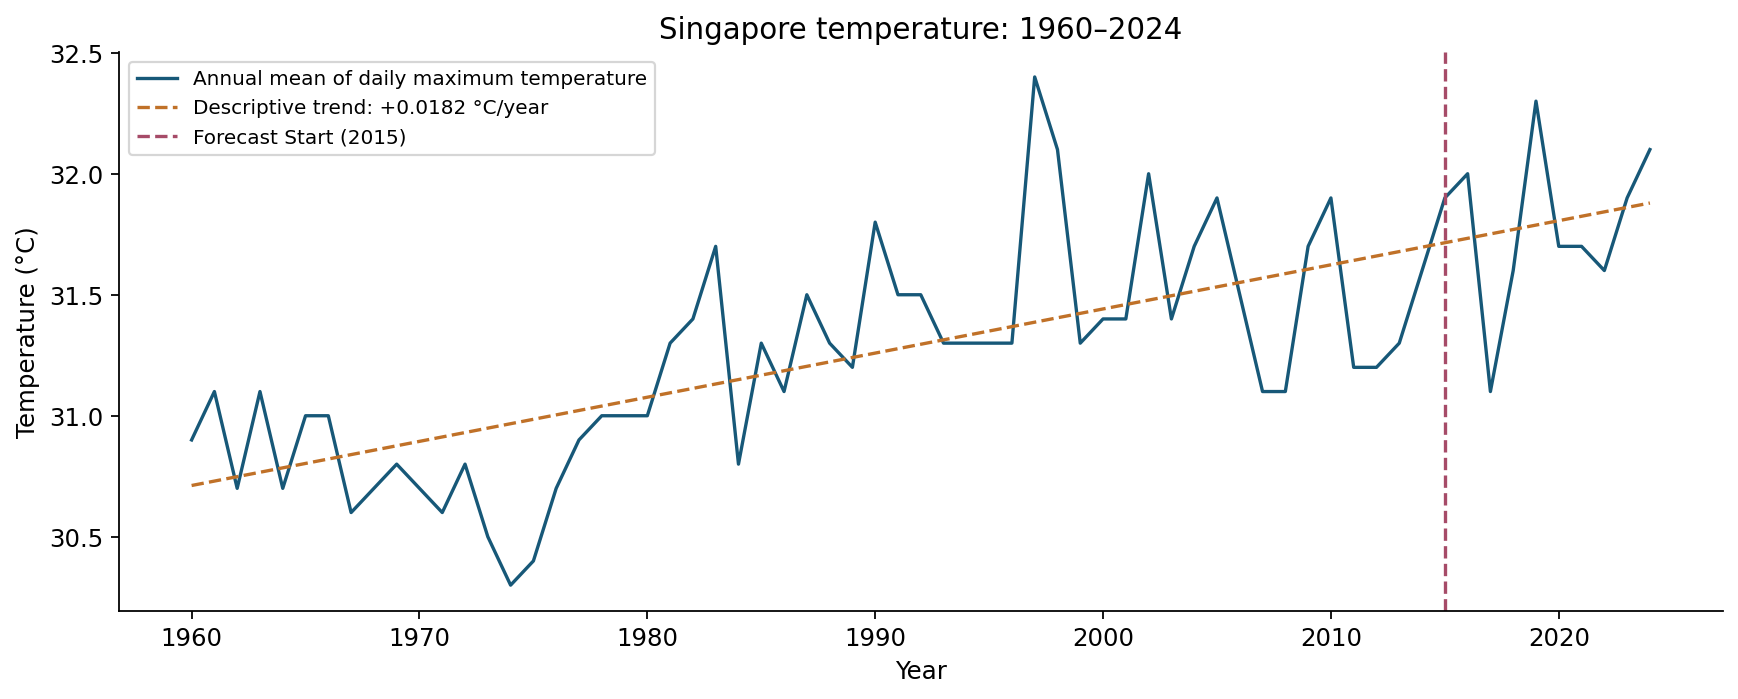

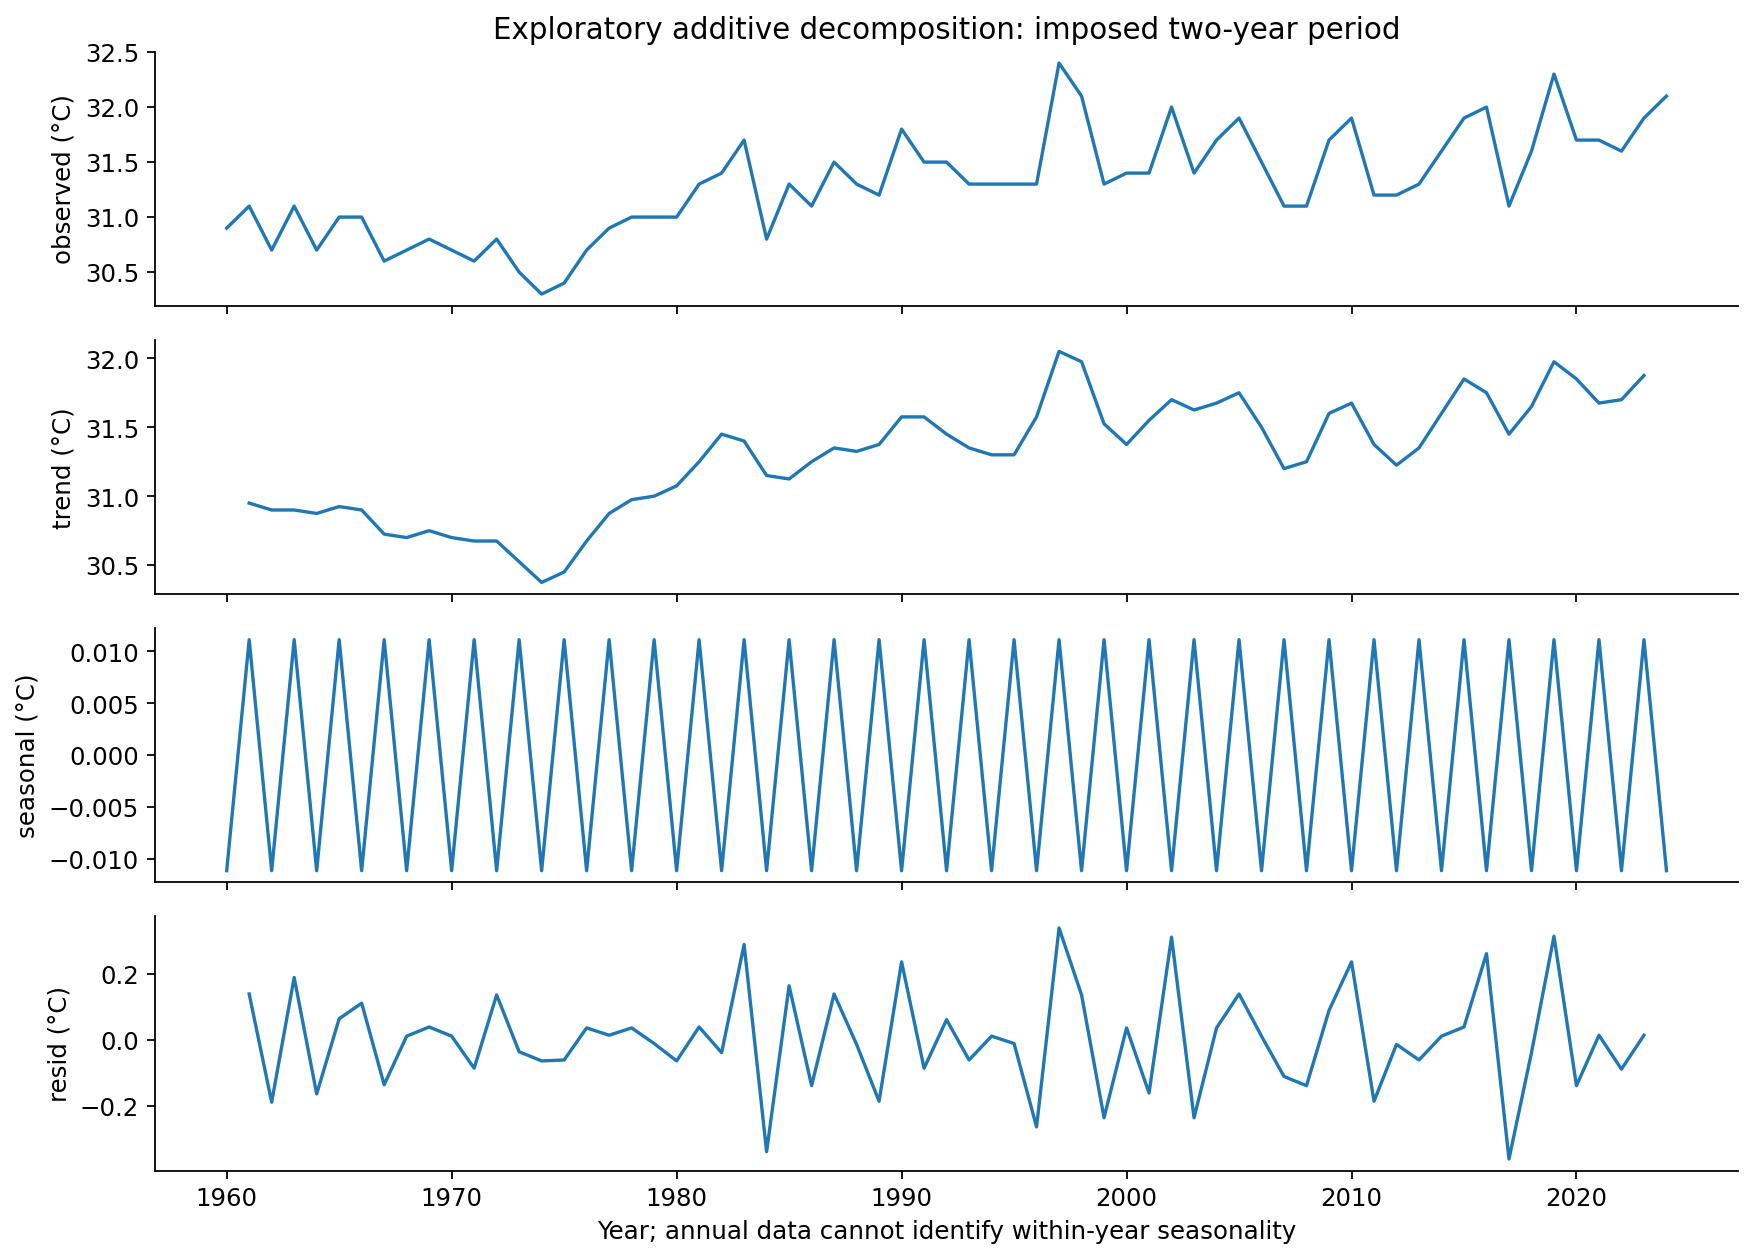

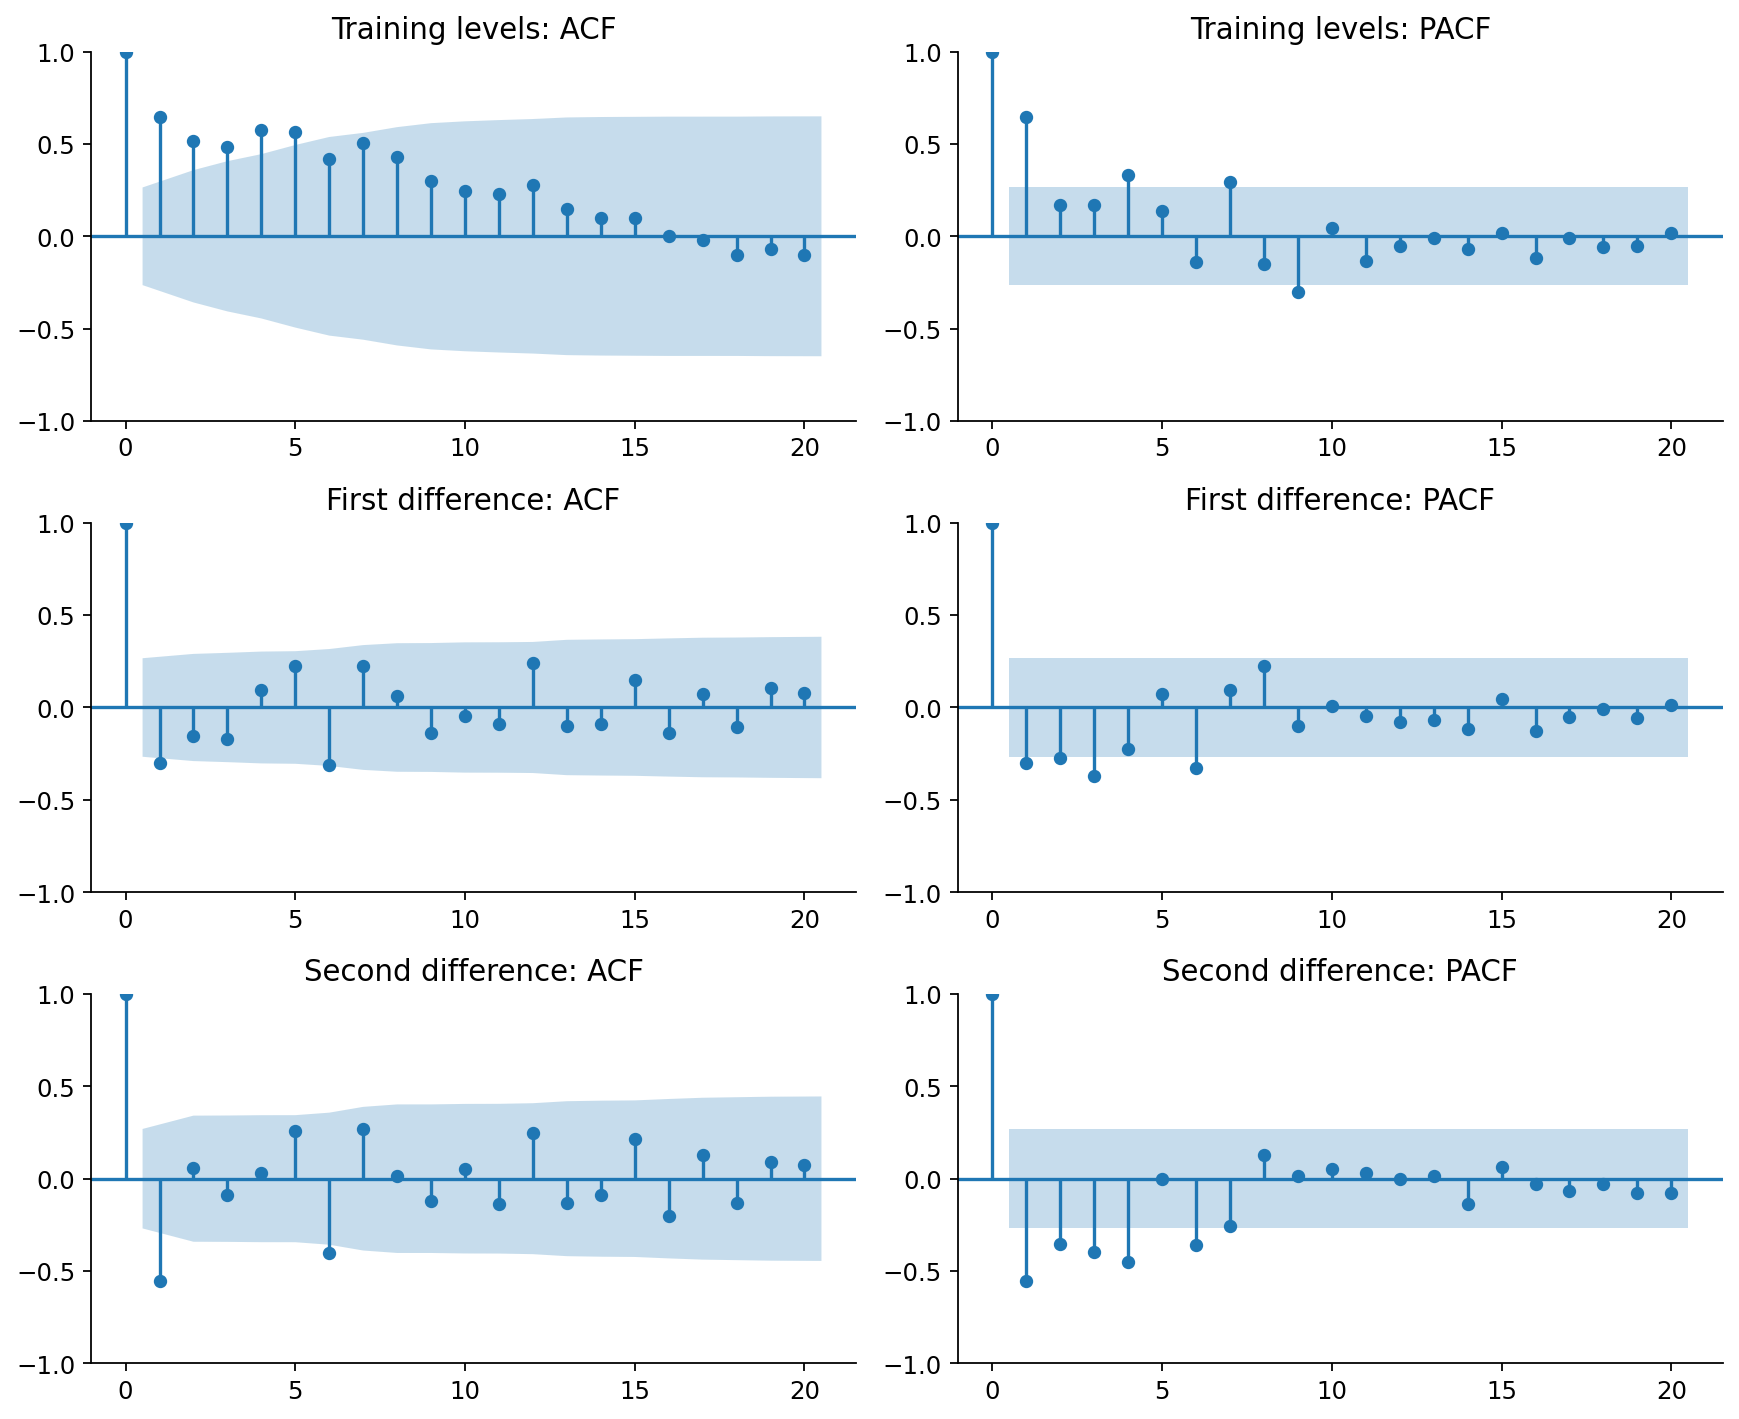

,trend_c,imposed_period_2_c,residual_c
year,,,
2020-01-01,31.850,-0.011114,-0.138886
2021-01-01,31.675,0.011114,0.013886
2022-01-01,31.700,-0.011114,-0.088886
2023-01-01,31.875,0.011114,0.013886
2024-01-01,NaN,-0.011114,NaN


In [3]:
print(f'Descriptive trend: {result["trend_c_per_year"]:.7f} °C/year')
display(result['stationarity'])
display(Image(filename=str(PROJECT / 'outputs/figures/temperature_trend.png')))
display(Image(filename=str(PROJECT / 'outputs/figures/exploratory_decomposition.png')))
display(Image(filename=str(PROJECT / 'outputs/figures/stationarity_diagnostics.png')))
d = result['decomposition']
display(pd.DataFrame({'trend_c':d.trend, 'imposed_period_2_c':d.seasonal, 'residual_c':d.resid}).tail())

## 4. SES baseline and ARIMA candidates
The chronological holdout comprises 2015–2024, with no refitting between horizons. SES uses estimated initialization and optimized smoothing. Eight low-order ARIMA candidates are compared by training AIC; the preserved selected model is ARIMA(0,1,1) without drift. Read optimizer convergence flags with AIC rankings.

In [4]:
print('SES smoothing level:', result['models']['SES'].params['smoothing_level'])
print('SES initial level:', result['models']['SES'].params['initial_level'])
display(result['arima_candidates'])
print(result['models']['ARIMA'].summary())
display(result['ses_interval'])

SES smoothing level: 0.30624161700183694
SES initial level: 30.909795382240592


,model,trend,AIC,converged
6,"ARIMA(0, 1, 1)",n,34.564539,True
0,"ARIMA(1, 1, 1)",n,35.301112,True
7,"ARIMA(0, 1, 1)",t,35.981124,True
1,"ARIMA(1, 1, 1)",t,36.315036,True
4,"ARIMA(1, 1, 0)",n,43.516149,True
5,"ARIMA(1, 1, 0)",t,45.427203,True
2,"ARIMA(0, 1, 0)",n,46.665131,True
3,"ARIMA(0, 1, 0)",t,48.597315,True


                               SARIMAX Results                                
Dep. Variable:          temperature_c   No. Observations:                   55
Model:                 ARIMA(0, 1, 1)   Log Likelihood                 -15.282
Date:                Fri, 09 Oct 2026   AIC                             34.565
Time:                        17:42:02   BIC                             38.543
Sample:                    01-01-1960   HQIC                            36.099
                         - 01-01-2014                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.6808      0.084     -8.088      0.000      -0.846      -0.516
sigma2         0.1019      0.017      5.919      0.000       0.068       0.136
Ljung-Box (L1) (Q):                   0.59   Jarque-

,lower_c,upper_c
year,,
2015-01-01,30.794559,32.025753
2016-01-01,30.727038,32.106165
2017-01-01,30.681841,32.129412
2018-01-01,30.699390,32.121529
2019-01-01,30.696378,32.163795
2020-01-01,30.668828,32.236485
2021-01-01,30.647158,32.250976
2022-01-01,30.615140,32.237706
2023-01-01,30.597327,32.352069


## 5. Rainfall association and conditional ARIMAX
Full-sample Pearson correlation and CCF are exploratory and include holdout years. Association does not establish a rainfall effect. The no-intercept OLS is retained as an intermediate diagnostic. ARIMAX uses observed same-year holdout rainfall, so this is a conditional retrospective comparison rather than an operational forecast.

Full-sample Pearson r: -0.303226


,lag_years,CCF,approx_95_bound
0,0,-0.303226,0.243108
1,1,-0.177713,0.243108
2,2,0.043532,0.243108
3,3,0.098146,0.243108
4,4,-0.083494,0.243108
5,5,-0.207757,0.243108
6,6,-0.128028,0.243108
7,7,-0.149218,0.243108
8,8,-0.066964,0.243108
9,9,0.054118,0.243108


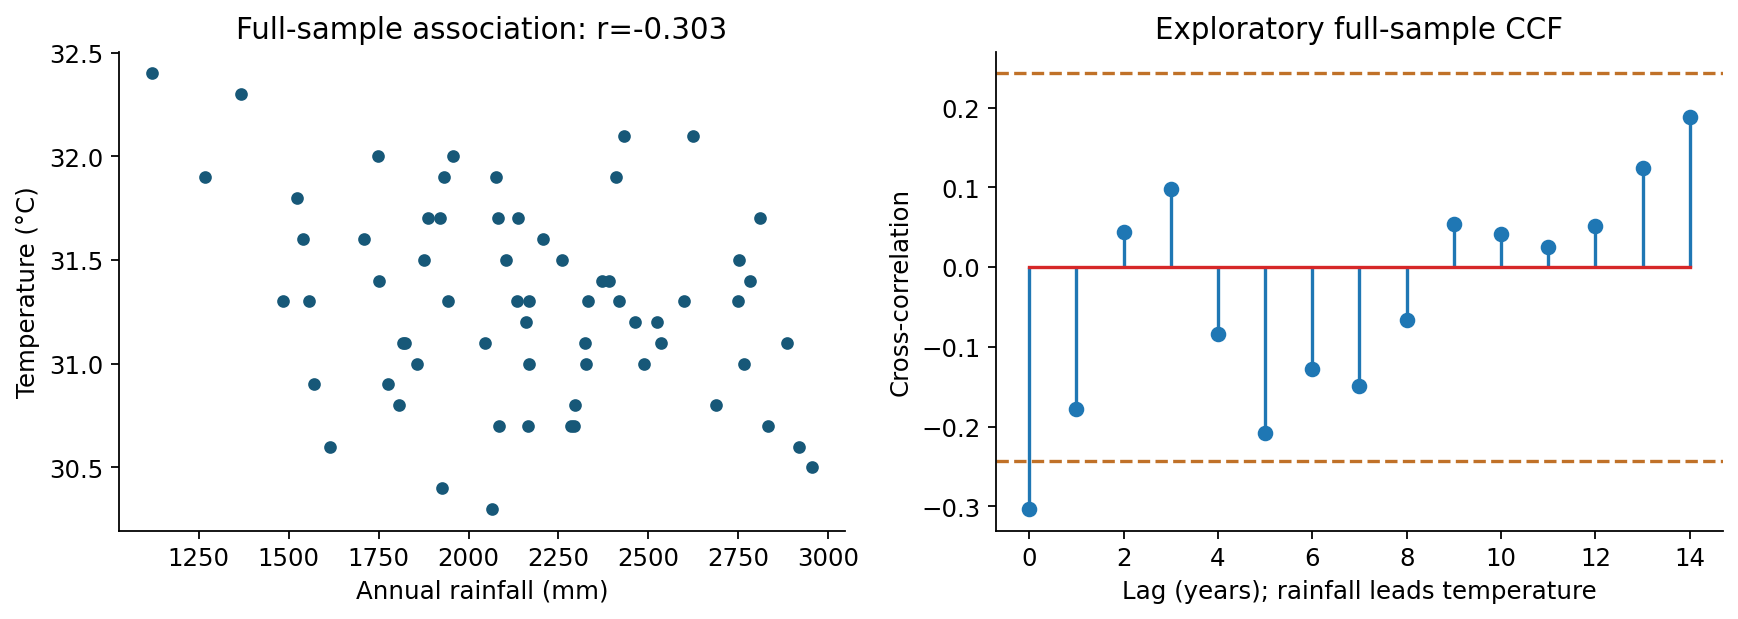

                                 OLS Regression Results                                
Dep. Variable:                     yt   R-squared (uncentered):                   0.963
Model:                            OLS   Adj. R-squared (uncentered):              0.962
Method:                 Least Squares   F-statistic:                              1386.
Date:                Fri, 09 Oct 2026   Prob (F-statistic):                    3.46e-40
Time:                        17:42:02   Log-Likelihood:                         -176.98
No. Observations:                  55   AIC:                                      356.0
Df Residuals:                      54   BIC:                                      358.0
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

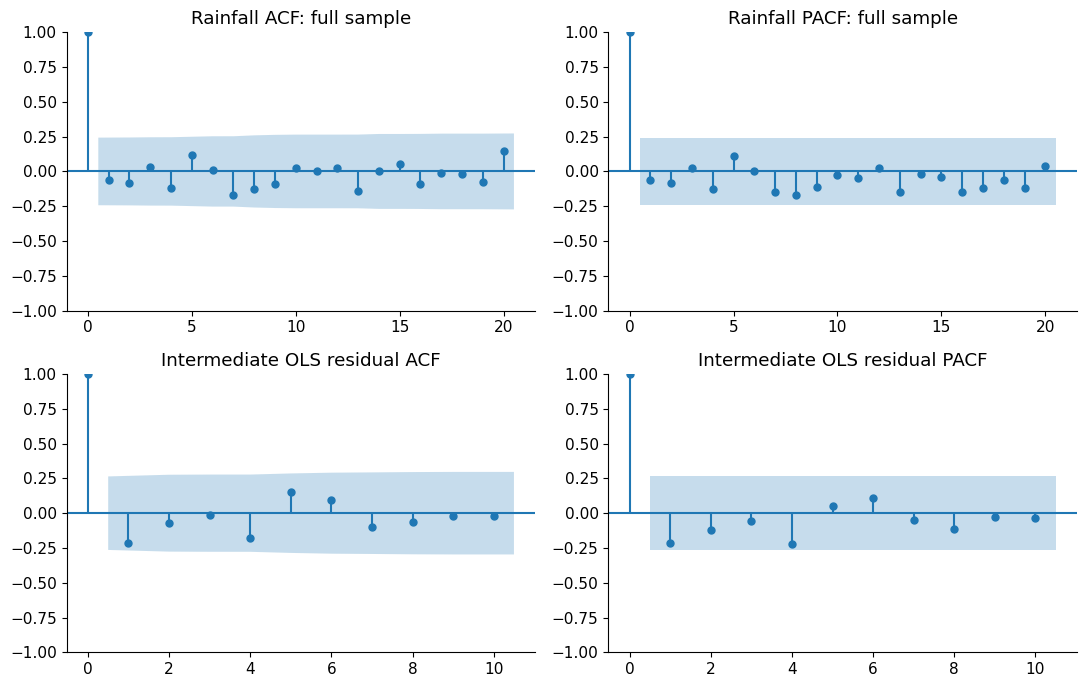

,model,trend,AIC,converged
4,"ARIMAX(1, 0, 0)",c,24.481536,True
10,"ARIMAX(1, 0, 1)",c,25.259554,True
7,"ARIMAX(0, 0, 1)",c,42.036019,False
1,"ARIMAX(0, 0, 0)",c,233.219619,True
2,"ARIMAX(0, 0, 0)",t,355.284102,True
8,"ARIMAX(0, 0, 1)",t,356.969568,True
6,"ARIMAX(0, 0, 1)",n,356.986574,True
5,"ARIMAX(1, 0, 0)",t,356.997285,True
3,"ARIMAX(1, 0, 0)",n,357.658504,True
0,"ARIMAX(0, 0, 0)",n,357.964734,True


                               SARIMAX Results                                
Dep. Variable:          temperature_c   No. Observations:                   55
Model:                 ARIMA(1, 0, 0)   Log Likelihood                  -8.241
Date:                Fri, 09 Oct 2026   AIC                             24.482
Time:                        17:42:02   BIC                             32.511
Sample:                    01-01-1960   HQIC                            27.587
                         - 01-01-2014                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         31.8459      0.167    190.787      0.000      31.519      32.173
xt0           -0.0003   5.94e-05     -5.319      0.000      -0.000      -0.000
ar.L1          0.7403      0.080      9.236      0.0

In [5]:
print(f'Full-sample Pearson r: {result["correlation"]:.6f}')
display(result['cross_correlation'])
display(Image(filename=str(PROJECT / 'outputs/figures/rainfall_association.png')))
print(result['ols'].summary())
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
plot_acf(data.rainfall_mm, lags=20, ax=axes[0,0], title='Rainfall ACF: full sample')
plot_pacf(data.rainfall_mm, lags=20, ax=axes[0,1], method='ywm', title='Rainfall PACF: full sample')
plot_acf(result['ols'].resid, lags=10, ax=axes[1,0], title='Intermediate OLS residual ACF')
plot_pacf(result['ols'].resid, lags=10, ax=axes[1,1], method='ywm', title='Intermediate OLS residual PACF')
plt.tight_layout()
plt.show()
plt.close(fig)
display(result['arimax_candidates'])
print(result['models']['ARIMAX'].summary())

## 6. Residual diagnostics and prediction intervals
Residual plots support model review, not proof of independence. The initial ARIMA residual is omitted from its public Q–Q/ACF views because it reflects initialization. Shapiro–Wilk non-rejection does not prove normality. SES intervals use 1,000 additive simulations with seed 64; ARIMAX intervals condition on supplied rainfall.

,model,residual_observations,Shapiro_W,Shapiro_p
0,ARIMA,54,0.972369,0.244623
1,ARIMAX,55,0.988944,0.892670


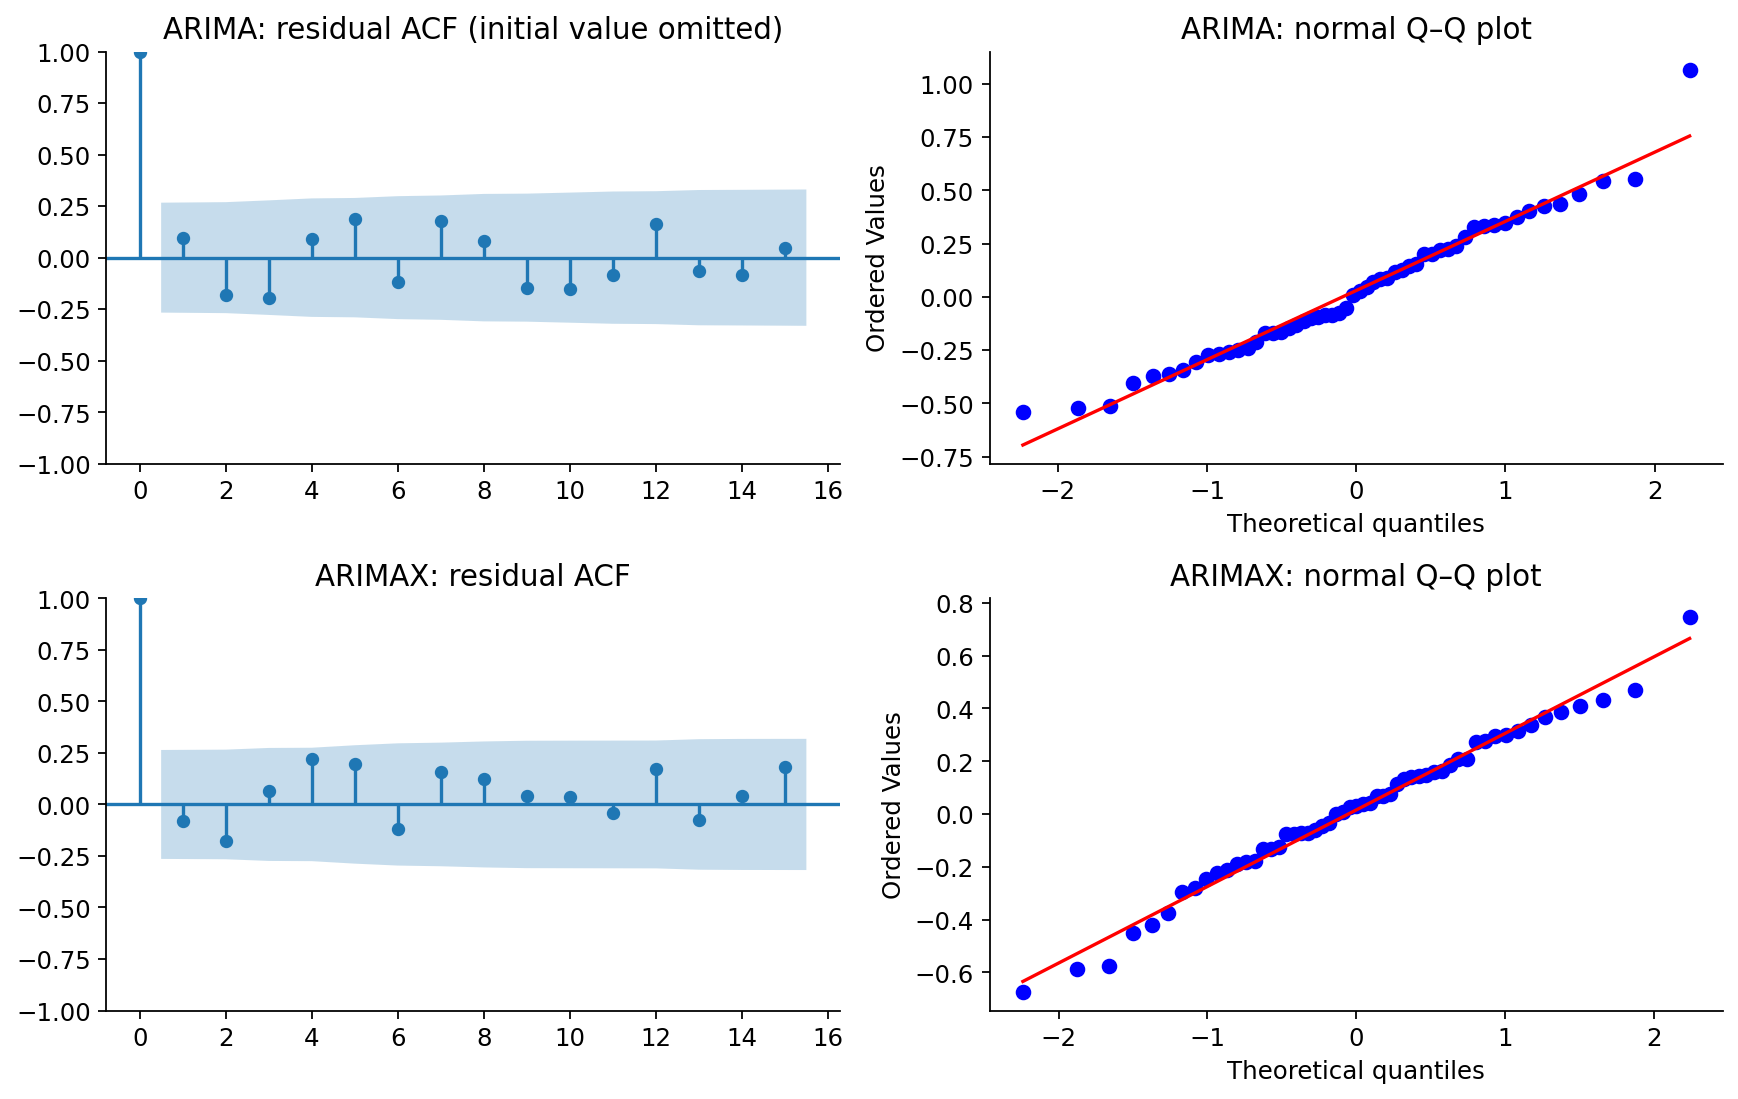

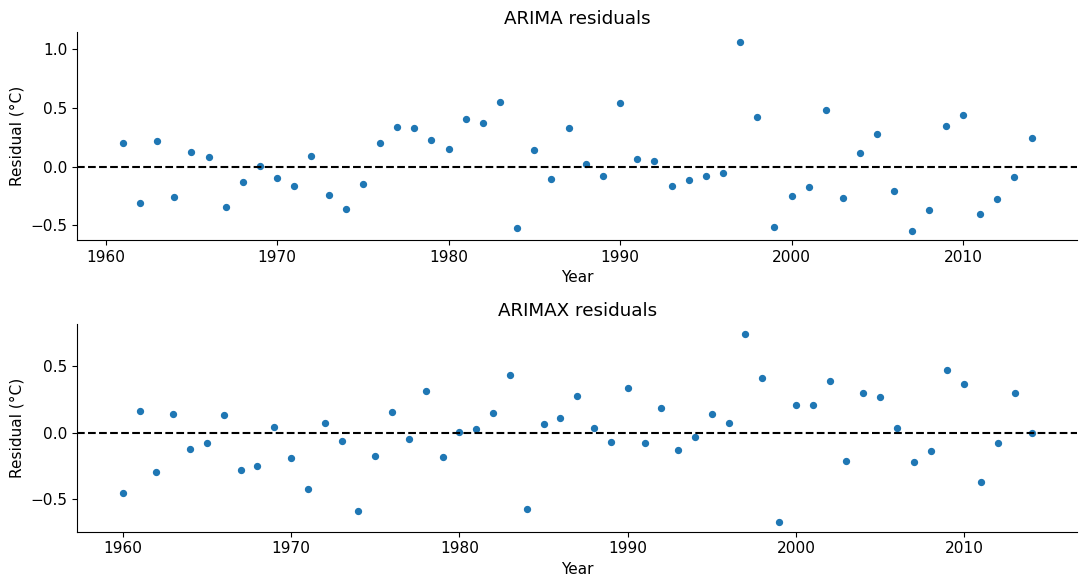

,lower temperature_c,upper temperature_c
2015-01-01,30.810091,32.061609
2016-01-01,30.778993,32.092707
2017-01-01,30.749302,32.122398
2018-01-01,30.720843,32.150857
2019-01-01,30.693474,32.178226
2020-01-01,30.667079,32.204621
2021-01-01,30.641560,32.230140
2022-01-01,30.616837,32.254864
2023-01-01,30.592838,32.278863
2024-01-01,30.569503,32.302197


,lower temperature_c,upper temperature_c
2015-01-01,31.077718,32.169164
2016-01-01,30.680642,32.038619
2017-01-01,30.555114,32.038988
2018-01-01,30.604077,32.152610
2019-01-01,30.675825,32.258674
2020-01-01,30.488714,32.090057
2021-01-01,30.181825,31.793214
2022-01-01,30.361801,31.978669
2023-01-01,30.290229,31.910091
2024-01-01,30.278674,31.900175


In [6]:
display(result['diagnostics'])
display(Image(filename=str(PROJECT / 'outputs/figures/residual_diagnostics.png')))
fig, axes = plt.subplots(2, 1, figsize=(11, 6))
for ax, name in zip(axes, ['ARIMA','ARIMAX']):
    residual = result['models'][name].resid
    if name == 'ARIMA': residual = residual.iloc[1:]
    ax.scatter(residual.index.year, residual.values, s=18)
    ax.axhline(0, color='black', linestyle='--')
    ax.set(title=name+' residuals', xlabel='Year', ylabel='Residual (°C)')
plt.tight_layout()
plt.show()
plt.close(fig)
display(result['arima_fc'].conf_int())
display(result['arimax_fc'].conf_int())

## 7. Holdout evaluation and decision
MAE and RMSE are in °C, MSE in °C². MAPE is secondary because Celsius has an arbitrary zero. Negative R² indicates squared errors exceed the holdout mean reference, which is unavailable at the historical forecast origin. Compare candidate complexity with actual holdout performance.

,model,MAPE_pct,MAE_c,MSE_c2,RMSE_c,R2,AIC
0,SES,1.3200,0.4212,0.2242,0.4735,-1.2673,-122.6132
1,ARIMA,1.3203,0.4213,0.2243,0.4736,-1.2682,34.5645
2,ARIMAX,1.7340,0.5532,0.3790,0.6156,-2.8321,24.4815


,actual_c,SES,ARIMA,ARIMAX,ARIMA_error_c,ARIMAX_error_c
year,,,,,,
2015-01-01,31.9,31.435974,31.43585,31.623441,-0.46415,-0.276559
2016-01-01,32.0,31.435974,31.43585,31.359631,-0.56415,-0.640369
2017-01-01,31.1,31.435974,31.43585,31.297051,0.33585,0.197051
2018-01-01,31.6,31.435974,31.43585,31.378343,-0.16415,-0.221657
2019-01-01,32.3,31.435974,31.43585,31.467249,-0.86415,-0.832751
2020-01-01,31.7,31.435974,31.43585,31.289385,-0.26415,-0.410615
2021-01-01,31.7,31.435974,31.43585,30.987520,-0.26415,-0.712480
2022-01-01,31.6,31.435974,31.43585,31.170235,-0.16415,-0.429765
2023-01-01,31.9,31.435974,31.43585,31.100160,-0.46415,-0.799840


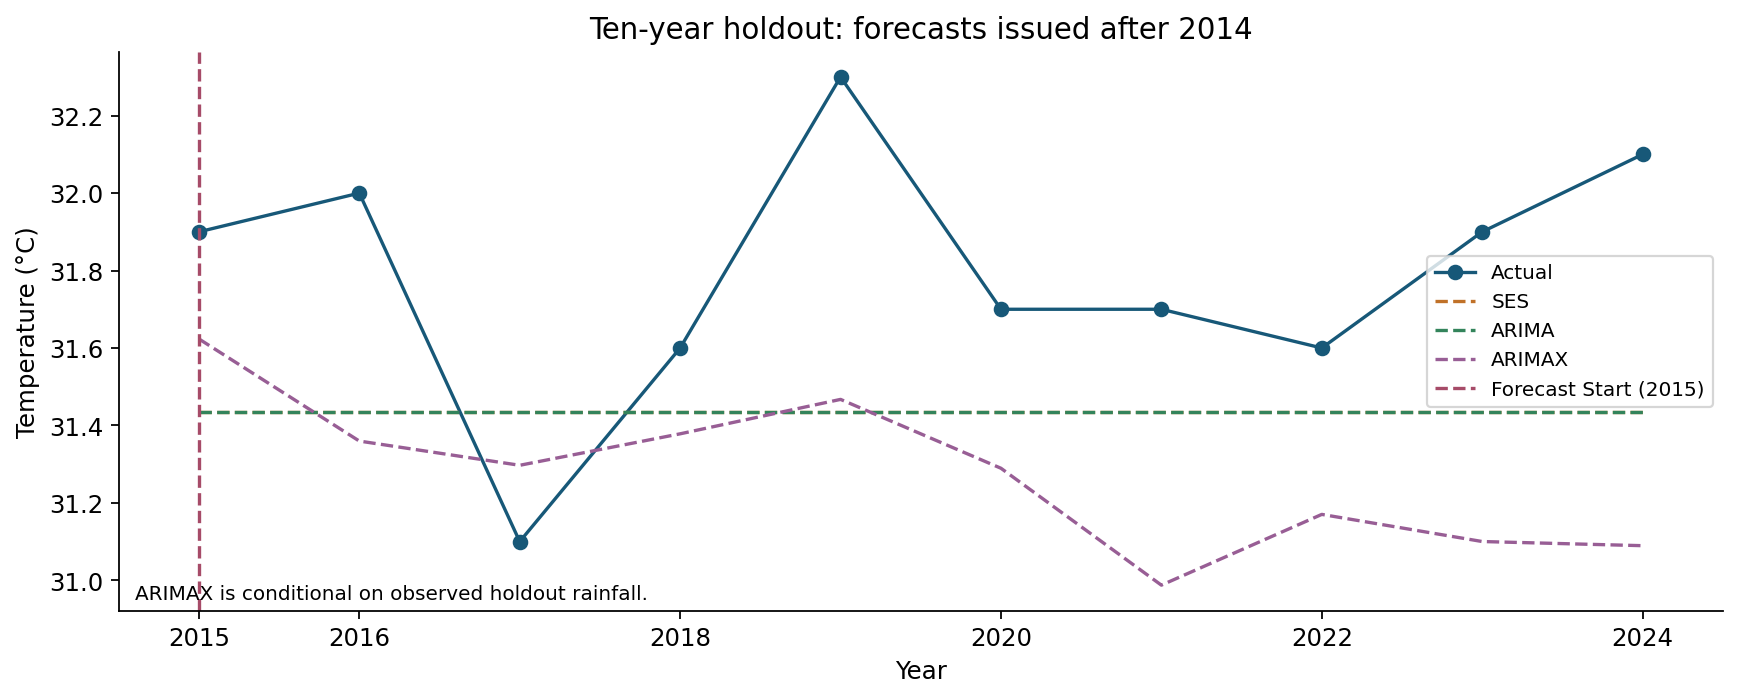

In [7]:
display(result['metrics'].round(4))
display(result['forecasts'].assign(ARIMA_error_c=lambda x: x.ARIMA-x.actual_c, ARIMAX_error_c=lambda x:x.ARIMAX-x.actual_c))
display(Image(filename=str(PROJECT / 'outputs/figures/holdout_comparison.png')))
assert result['metrics'].set_index('model').loc['ARIMAX', 'RMSE_c'] > result['metrics'].set_index('model').loc['ARIMA', 'RMSE_c']

SES and ARIMA have nearly identical holdout errors. Adding rainfall worsens the conditional comparison. Keep the simple benchmark, then require further rolling-origin validation with training-only feature exploration and realistic external-input availability. No operational impact or statistical significance of the model error difference was measured.

## 8. Multi-year scenario
The original scenario extends the model fitted through 2014 to 2030. Label its information cutoff explicitly. Flat point forecasts arise from the no-drift specification; model intervals do not account for every structural or model-selection risk.

Future scenario information cutoff: 2014


temperature_c,mean,mean_se,mean_ci_lower,mean_ci_upper
2025-01-01,31.43585,0.453615,30.546781,32.324919
2026-01-01,31.43585,0.464919,30.524625,32.347075
2027-01-01,31.43585,0.475955,30.502995,32.368705
2028-01-01,31.43585,0.486741,30.481856,32.389844
2029-01-01,31.43585,0.497292,30.461175,32.410525
2030-01-01,31.43585,0.507625,30.440924,32.430777


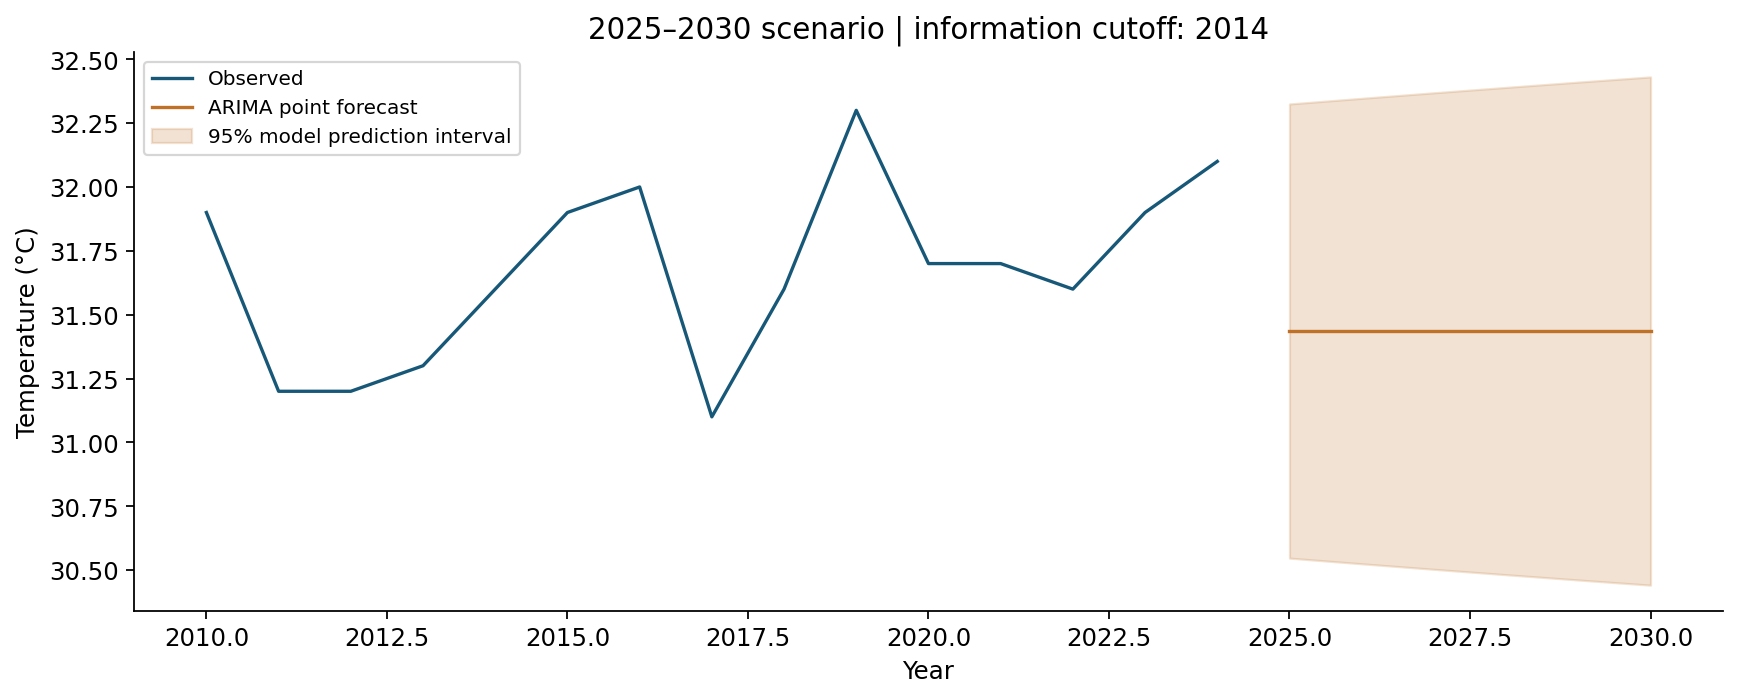

In [8]:
print('Future scenario information cutoff:', result['future_origin'])
display(result['future'])
display(Image(filename=str(PROJECT / 'outputs/figures/future_scenario.png')))

## 9. Planning recommendations and scope
Use a simple baseline in every model review. Proposed validation measures are MAE/RMSE by annual horizon, bias in °C, empirical 95% interval coverage and interval width. Before operational use, obtain daily weather and matched operational records. The annual data support a model comparison, not heat-safety thresholds, cooling-demand estimates or cost-saving claims. See the decision report for the complete proposal and limitations.